In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("reflux_sensitivity.csv")
df.columns = df.columns.str.replace(r"[\n]", " ", regex=True).str.strip()
df = df.dropna(axis=1, how="all")

df.head()

,Row/Case,Status,VARY 1 B2 COL-SPEC MOLE-RR,REBDUTY CAL/SEC,CONDDUTY CAL/SEC,BPURITY,TPURITY
0,1,OK,1.0,223461.055,-206503.796,0.921182,0.932369
1,2,OK,1.5,273411.112,-255806.271,0.978207,0.981463
2,3,OK,2.0,324038.598,-306269.631,0.992099,0.993294
3,4,OK,2.5,374911.654,-357099.024,0.995752,0.996397
4,5,OK,3.0,425843.420,-408013.364,0.997218,0.997640


In [3]:
print(df.columns)
print(df.dtypes)
df.describe()

Index(['Row/Case', 'Status', 'VARY   1 B2       COL-SPEC MOLE-RR',
       'REBDUTY      CAL/SEC', 'CONDDUTY     CAL/SEC', 'BPURITY', 'TPURITY'],
      dtype='object')
Row/Case                                int64
Status                                 object
VARY   1 B2       COL-SPEC MOLE-RR    float64
REBDUTY      CAL/SEC                  float64
CONDDUTY     CAL/SEC                  float64
BPURITY                               float64
TPURITY                               float64
dtype: object


,Row/Case,VARY 1 B2 COL-SPEC MOLE-RR,REBDUTY CAL/SEC,CONDDUTY CAL/SEC,BPURITY,TPURITY
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,5.000000,3.000000,426073.160222,-408367.129111,0.986483,0.988442
std,2.738613,1.369306,139224.982235,139021.391976,0.025350,0.021754
min,1.000000,1.000000,223461.055000,-611852.822000,0.921182,0.932369
25%,3.000000,2.000000,324038.598000,-509917.421000,0.992099,0.993294
50%,5.000000,3.000000,425843.420000,-408013.364000,0.997218,0.997640
75%,7.000000,4.000000,527761.600000,-306269.631000,0.998392,0.998637
max,9.000000,5.000000,629702.670000,-206503.796000,0.998865,0.999038


In [4]:
df = df[
    [
        "VARY   1 B2       COL-SPEC MOLE-RR",
        "REBDUTY      CAL/SEC",
        "CONDDUTY     CAL/SEC",
        "BPURITY",
        "TPURITY"
    ]
]

df.head()


,VARY 1 B2 COL-SPEC MOLE-RR,REBDUTY CAL/SEC,CONDDUTY CAL/SEC,BPURITY,TPURITY
0,1.0,223461.055,-206503.796,0.921182,0.932369
1,1.5,273411.112,-255806.271,0.978207,0.981463
2,2.0,324038.598,-306269.631,0.992099,0.993294
3,2.5,374911.654,-357099.024,0.995752,0.996397
4,3.0,425843.420,-408013.364,0.997218,0.997640


In [5]:
df["TOTAL_ENERGY      CAL/SEC"] = (
    abs(df["REBDUTY      CAL/SEC"])
    + abs(df["CONDDUTY     CAL/SEC"])
)

df.head()

,VARY 1 B2 COL-SPEC MOLE-RR,REBDUTY CAL/SEC,CONDDUTY CAL/SEC,BPURITY,TPURITY,TOTAL_ENERGY CAL/SEC
0,1.0,223461.055,-206503.796,0.921182,0.932369,429964.851
1,1.5,273411.112,-255806.271,0.978207,0.981463,529217.383
2,2.0,324038.598,-306269.631,0.992099,0.993294,630308.229
3,2.5,374911.654,-357099.024,0.995752,0.996397,732010.678
4,3.0,425843.420,-408013.364,0.997218,0.997640,833856.784


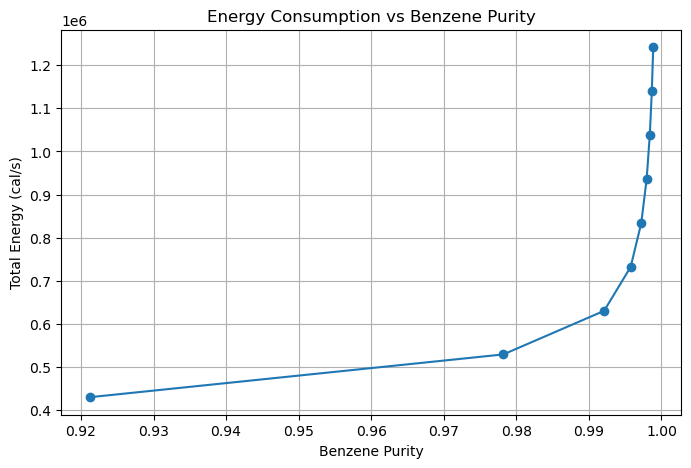

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    df["BPURITY"],
    df["TOTAL_ENERGY      CAL/SEC"],
    marker="o"
)

plt.xlabel("Benzene Purity")
plt.ylabel("Total Energy (cal/s)")
plt.title("Energy Consumption vs Benzene Purity")

plt.grid(True)

plt.show()

In [7]:
df["SLOPE"] = (
    df["TOTAL_ENERGY      CAL/SEC"].diff()
    /
    df["BPURITY"].diff()
)

df

,VARY 1 B2 COL-SPEC MOLE-RR,REBDUTY CAL/SEC,CONDDUTY CAL/SEC,BPURITY,TPURITY,TOTAL_ENERGY CAL/SEC,SLOPE
0,1.0,223461.055,-206503.796,0.921182,0.932369,429964.851,NaN
1,1.5,273411.112,-255806.271,0.978207,0.981463,529217.383,1.740504e+06
2,2.0,324038.598,-306269.631,0.992099,0.993294,630308.229,7.276864e+06
3,2.5,374911.654,-357099.024,0.995752,0.996397,732010.678,2.784114e+07
4,3.0,425843.420,-408013.364,0.997218,0.997640,833856.784,6.950914e+07
5,3.5,476797.720,-458958.757,0.997958,0.998268,935756.477,1.376017e+08
6,4.0,527761.600,-509917.421,0.998392,0.998637,1037679.021,2.347040e+08
7,4.5,578730.613,-560883.076,0.998672,0.998874,1139613.689,3.643308e+08
8,5.0,629702.670,-611852.822,0.998865,0.999038,1241555.492,5.289139e+08


In [8]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [9]:
from kneed import KneeLocator

knee = KneeLocator(
    df["BPURITY"],
    df["TOTAL_ENERGY      CAL/SEC"],
    curve="convex",
    direction="increasing"
)

print(knee.knee)

0.998864928


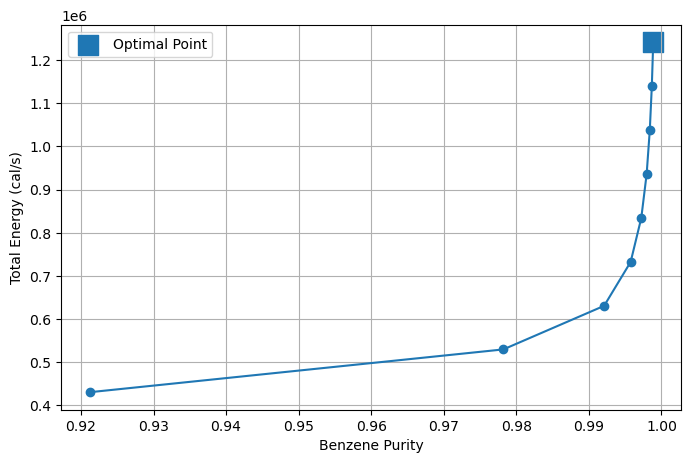

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["BPURITY"],
    df["TOTAL_ENERGY      CAL/SEC"],
    marker="o"
)

plt.scatter(
    knee.knee,
    knee.knee_y,
    marker= "s",
    s=200,
    label="Optimal Point"
)

plt.xlabel("Benzene Purity")
plt.ylabel("Total Energy (cal/s)")
plt.legend()

plt.grid(True)

plt.show()
